# Lab 10. Neural Networks for Text

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/wanghemath/Book-MathNLP/blob/main/labs/chapter-10-neural-networks-for-text.ipynb)

This lab accompanies Chapter 10 of **Mathematical Natural Language Processing**.

Earlier labs treated text representations such as count vectors, TF-IDF vectors, SVD coordinates, and word embeddings. In this lab, we make part of the representation **trainable**. A neural text classifier learns both:

1. a representation map from tokens to vectors, and  
2. a prediction map from vectors to class probabilities.

The main pipeline is

$$
\text{text}\to \text{token indices}\to \text{token embeddings}\to \text{pooled text vector}\to \text{softmax probabilities}.
$$

The notebook is intentionally small and from scratch. The goal is to understand the mathematics before using a deep-learning library.


## Learning goals

By the end of this lab, you should be able to:

1. describe a neural text classifier as a composition of maps;
2. build a vocabulary and encode texts as token-index lists;
3. implement softmax and cross-entropy safely;
4. explain why the gradient of softmax cross-entropy is $p-y$;
5. implement an averaged-embedding text classifier from scratch;
6. backpropagate through average pooling into an embedding matrix;
7. compare fixed bag-of-words features with trainable embeddings;
8. add a hidden ReLU layer and check all dimensions;
9. study temperature scaling and model confidence;
10. audit a tiny neural model for overfitting, unstable confidence, and token-level shortcuts.


## Mathematical background before programming

### 1. Text as a sequence of token indices

Let the vocabulary be

$$
V=\{0,1,\dots,d-1\}.
$$

A text is represented by a sequence

$$
x=(x_1,x_2,\dots,x_T), \qquad x_i\in V.
$$

The integer $x_i$ is not a numerical measurement. It is an index into a lookup table.

### 2. The embedding matrix

An embedding matrix is

$$
E\in \mathbb R^{d\times m}.
$$

The row $E_j\in \mathbb R^m$ is the vector for token $j$. For a sequence $x=(x_1,\dots,x_T)$, the embedding lookup gives

$$
M(x)=
\begin{bmatrix}
E_{x_1}\\
E_{x_2}\\
\vdots\\
E_{x_T}
\end{bmatrix}
\in \mathbb R^{T\times m}.
$$

A simple document representation is average pooling:

$$
h(x)=\frac{1}{T}\sum_{i=1}^T E_{x_i}\in \mathbb R^m.
$$

This is a useful first neural text model because the entire computation is transparent. Its limitation is also clear: average pooling ignores word order.

### 3. Logits, softmax, and cross-entropy

For a $K$-class problem, a linear output layer computes logits

$$
z(x)=h(x)W+b, \qquad W\in \mathbb R^{m\times K},\quad b\in \mathbb R^K.
$$

The softmax function converts logits into probabilities:

$$
p_k=\frac{\exp(z_k)}{\sum_{\ell=1}^K \exp(z_\ell)}.
$$

If the true class is $y$, the cross-entropy loss is

$$
L=-\log p_y.
$$

If $Y$ is the one-hot vector for the true label, then the key gradient is

$$
\frac{\partial L}{\partial z}=p-Y.
$$

For a batch, we average this gradient over the examples.

### 4. Backpropagation through average pooling

Suppose the loss gradient with respect to the pooled text vector is

$$
g_h=\frac{\partial L}{\partial h}\in \mathbb R^m.
$$

Since

$$
h=\frac{1}{T}\sum_{i=1}^T E_{x_i},
$$

each occurrence of a token in the document receives

$$
\frac{1}{T}g_h.
$$

If a token appears multiple times, the embedding row receives the sum of all of its occurrence-level contributions.


## Setup

This lab uses only `numpy`, `pandas`, and `matplotlib`. It does not require TensorFlow or PyTorch. Later labs can use deep-learning libraries after the mathematical objects are familiar.


In [1]:
import re
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(7243)
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

print("Setup complete.")


Setup complete.


# Part 1. A small text-classification dataset

We will classify short texts into two classes:

- class $1$: mathematical or technical language;
- class $0$: casual everyday language.

The dataset is deliberately small so that we can inspect every step. Small data is not enough for a production neural model, but it is excellent for learning the maps, dimensions, losses, and gradients.


In [2]:
raw_examples = [
    ("linear algebra and probability support machine learning models", 1),
    ("the theorem gives a clean mathematical proof", 1),
    ("statistics studies uncertainty data and inference", 1),
    ("gradient descent optimizes a differentiable objective", 1),
    ("a matrix factorization reveals low dimensional structure", 1),
    ("the classifier predicts labels from feature vectors", 1),
    ("eigenvalues describe important directions of a matrix", 1),
    ("regularization controls model complexity and variance", 1),
    ("the loss function measures prediction error", 1),
    ("a probability distribution assigns mass to outcomes", 1),
    ("neural networks learn useful representations from data", 1),
    ("optimization connects gradients parameters and training", 1),
    ("the movie was funny and relaxing to watch", 0),
    ("dinner with friends was tasty and cheerful", 0),
    ("the music made the evening feel warm", 0),
    ("a walk in the park was calm and pleasant", 0),
    ("the game was exciting but easy to follow", 0),
    ("coffee and breakfast made the morning better", 0),
    ("the story was simple charming and enjoyable", 0),
    ("we watched a show and laughed together", 0),
    ("the garden looked bright after the rain", 0),
    ("a family picnic made the weekend fun", 0),
    ("the recipe was easy and the soup was delicious", 0),
    ("music stories and food made the party lively", 0),
]

texts = [t for t, y in raw_examples]
labels = np.array([y for t, y in raw_examples], dtype=int)

# A fixed split keeps the lab reproducible and easy to discuss.
train_idx = np.array([0, 1, 2, 3, 4, 5, 8, 10, 12, 13, 14, 15, 16, 17, 20, 22])
test_idx = np.array([6, 7, 9, 11, 18, 19, 21, 23])

train_texts = [texts[i] for i in train_idx]
test_texts = [texts[i] for i in test_idx]
y_train = labels[train_idx]
y_test = labels[test_idx]

pd.DataFrame({"text": texts, "label": labels}).head(8)


,text,label
0,linear algebra and probability support machine...,1
1,the theorem gives a clean mathematical proof,1
2,statistics studies uncertainty data and inference,1
3,gradient descent optimizes a differentiable ob...,1
4,a matrix factorization reveals low dimensional...,1
5,the classifier predicts labels from feature ve...,1
6,eigenvalues describe important directions of a...,1
7,regularization controls model complexity and v...,1


## Interpretation question

Before training any model, read several examples from each class.

Which words are likely to be useful for classification? Which words might be misleading because they occur in many contexts, such as `and`, `the`, or `was`?


# Part 2. Tokenization, vocabulary, and indexed documents

A neural embedding layer expects integer token IDs. We therefore need a map

$$
\text{token} \mapsto \text{integer index}.
$$

We also add a special unknown-token index `<unk>` for words that appear in test examples but were not observed in training.


In [3]:
def tokenize(text):
    """Lowercase word tokenizer for a small educational corpus."""
    return re.findall(r"[a-z]+", text.lower())

train_tokens = [tokenize(t) for t in train_texts]
test_tokens = [tokenize(t) for t in test_texts]

counts = Counter(tok for doc in train_tokens for tok in doc)

# Reserve index 0 for unknown tokens.
vocab = {"<unk>": 0}
for tok, count in counts.most_common():
    vocab[tok] = len(vocab)

id_to_token = {j: tok for tok, j in vocab.items()}

print("Training examples:", len(train_texts))
print("Test examples:", len(test_texts))
print("Vocabulary size including <unk>:", len(vocab))
print("First 15 vocabulary items:")
print(list(vocab.items())[:15])


Training examples: 16
Test examples: 8
Vocabulary size including <unk>: 86
First 15 vocabulary items:
[('<unk>', 0), ('the', 1), ('and', 2), ('was', 3), ('a', 4), ('data', 5), ('from', 6), ('to', 7), ('made', 8), ('easy', 9), ('linear', 10), ('algebra', 11), ('probability', 12), ('support', 13), ('machine', 14)]


In [4]:
def encode(tokens, vocab):
    return [vocab.get(tok, vocab["<unk>"]) for tok in tokens]

X_train_ids = [encode(doc, vocab) for doc in train_tokens]
X_test_ids = [encode(doc, vocab) for doc in test_tokens]

for text, ids in list(zip(train_texts, X_train_ids))[:3]:
    print(text)
    print(ids)
    print()

unk_counts = [sum(1 for j in doc if j == vocab["<unk>"]) for doc in X_test_ids]
print("Unknown-token counts in test documents:", unk_counts)


linear algebra and probability support machine learning models
[10, 11, 2, 12, 13, 14, 15, 16]

the theorem gives a clean mathematical proof
[1, 17, 18, 4, 19, 20, 21]

statistics studies uncertainty data and inference
[22, 23, 24, 5, 2, 25]

Unknown-token counts in test documents: [5, 5, 4, 5, 4, 5, 4, 4]


## Shape check

The model sees a batch as a list of variable-length integer lists. For example, one document may have 7 tokens and another may have 9 tokens. Because we use average pooling, we do not need padding in this lab.

Later sequence models such as RNNs and Transformers usually use padded rectangular arrays together with masks.


# Part 3. Softmax and cross-entropy from scratch

Neural classifiers usually output **logits**, not probabilities. A logit is an unconstrained real number. Softmax transforms a vector of logits into a probability vector.

Numerical detail: we subtract the row maximum before exponentiating. This does not change the softmax probabilities, but prevents overflow when logits are large.


In [5]:
def softmax(Z):
    """Row-wise softmax. Z has shape (n, K)."""
    Z_shift = Z - Z.max(axis=1, keepdims=True)
    expZ = np.exp(Z_shift)
    return expZ / expZ.sum(axis=1, keepdims=True)


def cross_entropy(P, y, eps=1e-12):
    """Average cross-entropy for probability matrix P and integer labels y."""
    n = len(y)
    return -np.mean(np.log(P[np.arange(n), y] + eps))


def accuracy(P, y):
    return float(np.mean(P.argmax(axis=1) == y))

Z_demo = np.array([[2.0, 0.5], [0.2, 1.7], [0.0, 0.0]])
y_demo = np.array([0, 1, 1])
P_demo = softmax(Z_demo)

print("Probabilities:")
print(np.round(P_demo, 4))
print("Each row sums to:", np.round(P_demo.sum(axis=1), 4))
print("Cross-entropy:", cross_entropy(P_demo, y_demo))


Probabilities:
[[0.8176 0.1824]
 [0.1824 0.8176]
 [0.5    0.5   ]]
Each row sums to: [1. 1. 1.]
Cross-entropy: 0.3653245788403347


## The key gradient

For one example with softmax probability vector $p$ and one-hot label vector $Y$, the gradient of cross-entropy with respect to the logits is

$$
\frac{\partial L}{\partial z}=p-Y.
$$

For a batch of $n$ examples, we divide by $n$ because the loss is an average.


In [6]:
def softmax_cross_entropy_gradient(Z, y):
    """Gradient of average cross-entropy with respect to logits Z."""
    P = softmax(Z)
    G = P.copy()
    G[np.arange(len(y)), y] -= 1.0
    G /= len(y)
    return G

G_demo = softmax_cross_entropy_gradient(Z_demo, y_demo)
print(np.round(G_demo, 4))
print("Rows sum to zero because changing all logits by the same constant does not change softmax.")
print(np.round(G_demo.sum(axis=1), 8))


[[-0.0608  0.0608]
 [ 0.0608 -0.0608]
 [ 0.1667 -0.1667]]
Rows sum to zero because changing all logits by the same constant does not change softmax.
[-0. -0.  0.]


# Part 4. Fixed bag-of-words baseline

Before using trainable embeddings, we train a simple linear softmax classifier on fixed bag-of-words features.

For a document $x$, define a count vector

$$
\phi(x)\in \mathbb R^d.
$$

Then compute

$$
z=\phi(x)W+b.
$$

This is not yet a neural embedding model. It is a useful baseline because the representation is fixed.


In [7]:
def count_matrix(encoded_docs, vocab_size):
    Xmat = np.zeros((len(encoded_docs), vocab_size))
    for i, doc in enumerate(encoded_docs):
        for token_id in doc:
            Xmat[i, token_id] += 1.0
    # Use relative frequency so long texts do not automatically have larger norms.
    lengths = np.array([max(1, len(doc)) for doc in encoded_docs])
    Xmat = Xmat / lengths[:, None]
    return Xmat

B_train = count_matrix(X_train_ids, len(vocab))
B_test = count_matrix(X_test_ids, len(vocab))

print("B_train shape:", B_train.shape)
print("B_test shape:", B_test.shape)
print("First row nonzero features:")
for j in np.where(B_train[0] > 0)[0]:
    print(f"{id_to_token[j]:>15s}: {B_train[0, j]:.3f}")


B_train shape: (16, 86)
B_test shape: (8, 86)
First row nonzero features:
            and: 0.125
         linear: 0.125
        algebra: 0.125
    probability: 0.125
        support: 0.125
        machine: 0.125
       learning: 0.125
         models: 0.125


In [8]:
def train_linear_softmax(Xtr, ytr, Xte, yte, epochs=500, lr=1.0, l2=0.01, seed=1):
    rng_local = np.random.default_rng(seed)
    n, d = Xtr.shape
    K = int(max(ytr.max(), yte.max())) + 1
    W = 0.01 * rng_local.normal(size=(d, K))
    b = np.zeros(K)
    hist = []
    for epoch in range(epochs):
        Z = Xtr @ W + b
        P = softmax(Z)
        loss = cross_entropy(P, ytr) + 0.5 * l2 * np.sum(W * W)
        hist.append(loss)

        Gz = P.copy()
        Gz[np.arange(n), ytr] -= 1.0
        Gz /= n

        grad_W = Xtr.T @ Gz + l2 * W
        grad_b = Gz.sum(axis=0)

        W -= lr * grad_W
        b -= lr * grad_b

    train_P = softmax(Xtr @ W + b)
    test_P = softmax(Xte @ W + b)
    return W, b, hist, train_P, test_P

W_bow, b_bow, hist_bow, P_train_bow, P_test_bow = train_linear_softmax(
    B_train, y_train, B_test, y_test, epochs=600, lr=1.0, l2=0.02, seed=7243
)

print("Final train loss:", round(hist_bow[-1], 4))
print("Train accuracy:", accuracy(P_train_bow, y_train))
print("Test accuracy:", accuracy(P_test_bow, y_test))


Final train loss: 0.5715
Train accuracy: 1.0
Test accuracy: 0.75


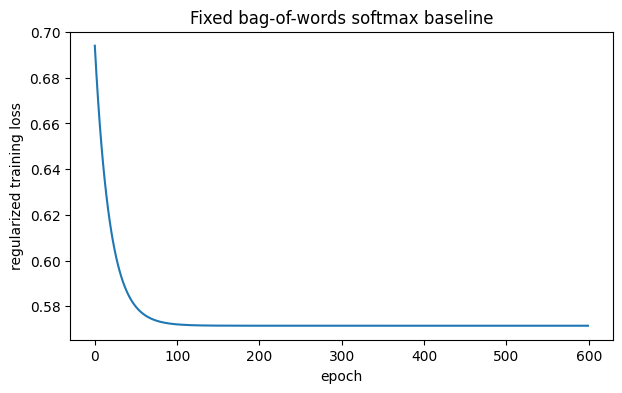

In [9]:
plt.figure(figsize=(7, 4))
plt.plot(hist_bow)
plt.xlabel("epoch")
plt.ylabel("regularized training loss")
plt.title("Fixed bag-of-words softmax baseline")
plt.show()


## Interpretation question

The bag-of-words baseline has one feature for each token. Which tokens get the strongest positive and negative weights?

For two classes, the useful direction is

$$
w_{\text{technical}}-w_{\text{casual}}.
$$


In [10]:
bow_direction = W_bow[:, 1] - W_bow[:, 0]
ranked = sorted([(id_to_token[j], bow_direction[j]) for j in range(len(vocab))], key=lambda t: t[1], reverse=True)

print("Most technical-associated bag-of-words features:")
for tok, score in ranked[:10]:
    print(f"{tok:>16s}  {score: .3f}")

print("\nMost casual-associated bag-of-words features:")
for tok, score in ranked[-10:]:
    print(f"{tok:>16s}  {score: .3f}")


Most technical-associated bag-of-words features:
               a   0.737
            data   0.697
            from   0.672
      prediction   0.439
           error   0.439
        function   0.439
        measures   0.439
            loss   0.439
       inference   0.394
     uncertainty   0.394

Most casual-associated bag-of-words features:
          dinner  -0.365
        cheerful  -0.365
            with  -0.365
           tasty  -0.365
            easy  -0.522
              to  -0.592
            made  -0.679
             and  -0.824
             was  -1.696
             the  -1.831


# Part 5. Averaged-embedding classifier

Now we make the representation trainable.

The model is

$$
\begin{aligned}
h(x) &= \frac{1}{T}\sum_{i=1}^T E_{x_i},\\
z(x) &= h(x)W+b,\\
p(x) &= \operatorname{softmax}(z(x)).
\end{aligned}
$$

Dimensions:

- vocabulary size: $d$;
- embedding dimension: $m$;
- number of classes: $K=2$;
- $E\in \mathbb R^{d\times m}$;
- $W\in \mathbb R^{m\times K}$;
- $b\in \mathbb R^K$.


In [11]:
def forward_avg_embedding(encoded_docs, E, W, b):
    """Forward pass for averaged-embedding classifier."""
    H = np.zeros((len(encoded_docs), E.shape[1]))
    for i, doc in enumerate(encoded_docs):
        H[i] = E[doc].mean(axis=0)
    Z = H @ W + b
    P = softmax(Z)
    return H, Z, P

# Dimension check
D = len(vocab)
m = 8
K = 2
E0 = 0.05 * rng.normal(size=(D, m))
W0 = 0.05 * rng.normal(size=(m, K))
b0 = np.zeros(K)

H0, Z0, P0 = forward_avg_embedding(X_train_ids, E0, W0, b0)
print("E shape:", E0.shape)
print("H shape:", H0.shape)
print("W shape:", W0.shape)
print("Z shape:", Z0.shape)
print("P shape:", P0.shape)
print("Initial loss:", cross_entropy(P0, y_train))


E shape: (86, 8)
H shape: (16, 8)
W shape: (8, 2)
Z shape: (16, 2)
P shape: (16, 2)
Initial loss: 0.6934035674794932


## Backpropagation formula for the averaged-embedding model

Let $n$ be the number of training examples. For the averaged loss,

$$
G_z=\frac{1}{n}(P-Y).
$$

Then

$$
\frac{\partial L}{\partial W}=H^TG_z,
\qquad
\frac{\partial L}{\partial b}=\sum_i G_{z,i},
$$

and

$$
G_h=G_zW^T.
$$

For document $i$ with token indices $x_{i,1},\dots,x_{i,T_i}$, each occurrence contributes

$$
\frac{1}{T_i}G_{h,i}
$$

to its embedding row.


In [12]:
def loss_and_grads_avg_embedding(encoded_docs, y, E, W, b, l2=0.0):
    """Compute loss and gradients for averaged-embedding classifier."""
    n = len(encoded_docs)
    H, Z, P = forward_avg_embedding(encoded_docs, E, W, b)
    loss = cross_entropy(P, y) + 0.5 * l2 * (np.sum(E * E) + np.sum(W * W))

    Gz = P.copy()
    Gz[np.arange(n), y] -= 1.0
    Gz /= n

    grad_W = H.T @ Gz + l2 * W
    grad_b = Gz.sum(axis=0)
    grad_H = Gz @ W.T

    grad_E = np.zeros_like(E)
    for i, doc in enumerate(encoded_docs):
        contribution = grad_H[i] / len(doc)
        for token_id in doc:
            grad_E[token_id] += contribution
    grad_E += l2 * E

    return loss, (grad_E, grad_W, grad_b), (H, Z, P)

loss0, (gE0, gW0, gb0), _ = loss_and_grads_avg_embedding(X_train_ids, y_train, E0, W0, b0, l2=0.001)
print("Loss:", loss0)
print("grad_E shape:", gE0.shape)
print("grad_W shape:", gW0.shape)
print("grad_b shape:", gb0.shape)


Loss: 0.6943226514395832
grad_E shape: (86, 8)
grad_W shape: (8, 2)
grad_b shape: (2,)


## Gradient check

A finite-difference gradient check verifies that the backpropagation code is consistent with the loss. For a parameter $\theta_j$,

$$
\frac{\partial L}{\partial \theta_j}\approx
\frac{L(\theta_j+\epsilon)-L(\theta_j-\epsilon)}{2\epsilon}.
$$

The numerical and analytic gradients should be close.


In [13]:
def finite_difference_check():
    E = E0.copy()
    W = W0.copy()
    b = b0.copy()
    eps = 1e-5
    l2 = 0.001

    loss, (grad_E, grad_W, grad_b), _ = loss_and_grads_avg_embedding(X_train_ids, y_train, E, W, b, l2=l2)

    checks = []

    # Check one embedding entry for a token that occurs in training.
    token_id = vocab["linear"]
    dim = 2
    E_plus = E.copy(); E_minus = E.copy()
    E_plus[token_id, dim] += eps
    E_minus[token_id, dim] -= eps
    L_plus = loss_and_grads_avg_embedding(X_train_ids, y_train, E_plus, W, b, l2=l2)[0]
    L_minus = loss_and_grads_avg_embedding(X_train_ids, y_train, E_minus, W, b, l2=l2)[0]
    numerical = (L_plus - L_minus) / (2 * eps)
    analytic = grad_E[token_id, dim]
    checks.append(("E[linear, 2]", analytic, numerical, abs(analytic - numerical)))

    # Check one output-layer entry.
    row, col = 3, 1
    W_plus = W.copy(); W_minus = W.copy()
    W_plus[row, col] += eps
    W_minus[row, col] -= eps
    L_plus = loss_and_grads_avg_embedding(X_train_ids, y_train, E, W_plus, b, l2=l2)[0]
    L_minus = loss_and_grads_avg_embedding(X_train_ids, y_train, E, W_minus, b, l2=l2)[0]
    numerical = (L_plus - L_minus) / (2 * eps)
    analytic = grad_W[row, col]
    checks.append(("W[3, 1]", analytic, numerical, abs(analytic - numerical)))

    # Check one bias entry.
    col = 1
    b_plus = b.copy(); b_minus = b.copy()
    b_plus[col] += eps
    b_minus[col] -= eps
    L_plus = loss_and_grads_avg_embedding(X_train_ids, y_train, E, W, b_plus, l2=l2)[0]
    L_minus = loss_and_grads_avg_embedding(X_train_ids, y_train, E, W, b_minus, l2=l2)[0]
    numerical = (L_plus - L_minus) / (2 * eps)
    analytic = grad_b[col]
    checks.append(("b[1]", analytic, numerical, abs(analytic - numerical)))

    return pd.DataFrame(checks, columns=["parameter", "analytic", "finite_difference", "absolute_error"])

finite_difference_check().round(8)


,parameter,analytic,finite_difference,absolute_error
0,"E[linear, 2]",0.000264,0.000264,0.0
1,"W[3, 1]",-0.002739,-0.002739,0.0
2,b[1],0.000475,0.000475,0.0


# Part 6. Train the averaged-embedding model

We now optimize $E$, $W$, and $b$ with gradient descent. Because the data are tiny, the purpose is not benchmark performance. The purpose is to see how a trainable representation changes during learning.


In [14]:
def train_avg_embedding(encoded_train, y_train, encoded_test, y_test,
                        embedding_dim=8, epochs=800, lr=4.0, l2=0.001, seed=0):
    rng_local = np.random.default_rng(seed)
    D = len(vocab)
    K = 2
    E = 0.05 * rng_local.normal(size=(D, embedding_dim))
    W = 0.05 * rng_local.normal(size=(embedding_dim, K))
    b = np.zeros(K)

    history = []
    for epoch in range(epochs):
        loss, (grad_E, grad_W, grad_b), (_, _, P_train) = loss_and_grads_avg_embedding(
            encoded_train, y_train, E, W, b, l2=l2
        )
        history.append(loss)

        E -= lr * grad_E
        W -= lr * grad_W
        b -= lr * grad_b

    H_train, Z_train, P_train = forward_avg_embedding(encoded_train, E, W, b)
    H_test, Z_test, P_test = forward_avg_embedding(encoded_test, E, W, b)
    results = {
        "E": E, "W": W, "b": b,
        "history": history,
        "H_train": H_train, "P_train": P_train,
        "H_test": H_test, "P_test": P_test,
        "train_accuracy": accuracy(P_train, y_train),
        "test_accuracy": accuracy(P_test, y_test),
        "train_loss": cross_entropy(P_train, y_train),
        "test_loss": cross_entropy(P_test, y_test),
    }
    return results

avg_results = train_avg_embedding(
    X_train_ids, y_train, X_test_ids, y_test,
    embedding_dim=8, epochs=900, lr=4.0, l2=0.001, seed=7243
)

print("Final train loss:", round(avg_results["train_loss"], 4))
print("Final test loss:", round(avg_results["test_loss"], 4))
print("Train accuracy:", avg_results["train_accuracy"])
print("Test accuracy:", avg_results["test_accuracy"])


Final train loss: 0.0067
Final test loss: 0.4418
Train accuracy: 1.0
Test accuracy: 0.875


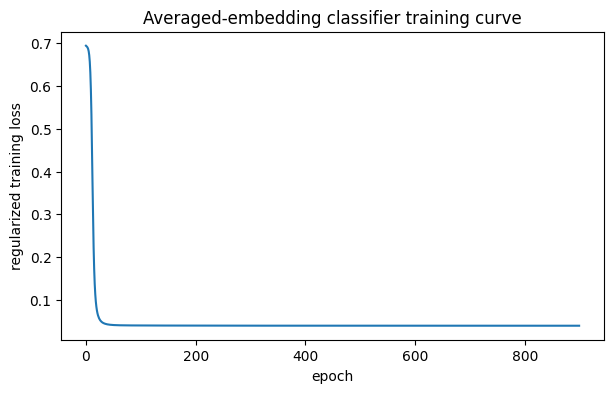

In [15]:
plt.figure(figsize=(7, 4))
plt.plot(avg_results["history"])
plt.xlabel("epoch")
plt.ylabel("regularized training loss")
plt.title("Averaged-embedding classifier training curve")
plt.show()


## Test-set predictions

Because this is a tiny dataset, do not over-interpret the test accuracy. Instead, inspect the predictions and ask whether the model is relying on meaningful words or accidental cues.


In [16]:
def prediction_table(texts, y, P):
    rows = []
    for text, label, probs in zip(texts, y, P):
        rows.append({
            "text": text,
            "true_label": int(label),
            "predicted": int(np.argmax(probs)),
            "prob_casual_0": probs[0],
            "prob_technical_1": probs[1],
            "confidence": float(np.max(probs)),
        })
    return pd.DataFrame(rows)

prediction_table(test_texts, y_test, avg_results["P_test"]).round(3)


,text,true_label,predicted,prob_casual_0,prob_technical_1,confidence
0,eigenvalues describe important directions of a...,1,1,0.031,0.969,0.969
1,regularization controls model complexity and v...,1,1,0.316,0.684,0.684
2,a probability distribution assigns mass to out...,1,1,0.061,0.939,0.939
3,optimization connects gradients parameters and...,1,1,0.316,0.684,0.684
4,the story was simple charming and enjoyable,0,0,0.975,0.025,0.975
5,we watched a show and laughed together,0,1,0.140,0.860,0.860
6,a family picnic made the weekend fun,0,0,0.558,0.442,0.558
7,music stories and food made the party lively,0,0,0.897,0.103,0.897


# Part 7. Inspect learned token directions

For a two-class averaged-embedding model, the class-separating direction is approximately

$$
W_{:,1}-W_{:,0}.
$$

The score of token $j$ in that direction is

$$
E_j\cdot (W_{:,1}-W_{:,0}).
$$

Large positive scores suggest association with class $1$; large negative scores suggest association with class $0$.


In [17]:
E = avg_results["E"]
W = avg_results["W"]
direction = W[:, 1] - W[:, 0]
token_scores = E @ direction

ranked = sorted([(id_to_token[j], token_scores[j], counts.get(id_to_token[j], 0)) for j in range(len(vocab))],
                key=lambda t: t[1], reverse=True)

print("Most technical-associated tokens:")
for tok, score, count in ranked[:12]:
    print(f"{tok:>16s}  score={score: .3f}  count={count}")

print("\nMost casual-associated tokens:")
for tok, score, count in ranked[-12:]:
    print(f"{tok:>16s}  score={score: .3f}  count={count}")


Most technical-associated tokens:
            from  score= 7.178  count=2
            data  score= 6.691  count=2
            loss  score= 6.075  count=1
        function  score= 6.058  count=1
           error  score= 6.048  count=1
      prediction  score= 6.046  count=1
        measures  score= 6.037  count=1
               a  score= 5.836  count=4
         theorem  score= 5.355  count=1
           clean  score= 5.343  count=1
           gives  score= 5.341  count=1
    mathematical  score= 5.340  count=1

Most casual-associated tokens:
        cheerful  score=-4.655  count=1
           tasty  score=-4.658  count=1
              in  score=-4.984  count=1
            walk  score=-5.003  count=1
            calm  score=-5.005  count=1
            park  score=-5.006  count=1
        pleasant  score=-5.020  count=1
              to  score=-6.418  count=2
            made  score=-7.796  count=2
             and  score=-8.731  count=7
             the  score=-15.233  count=13
            

## Visualizing the learned embedding space

We use SVD to project the learned token embeddings to two dimensions. This is only a visualization; the model was trained in eight dimensions.


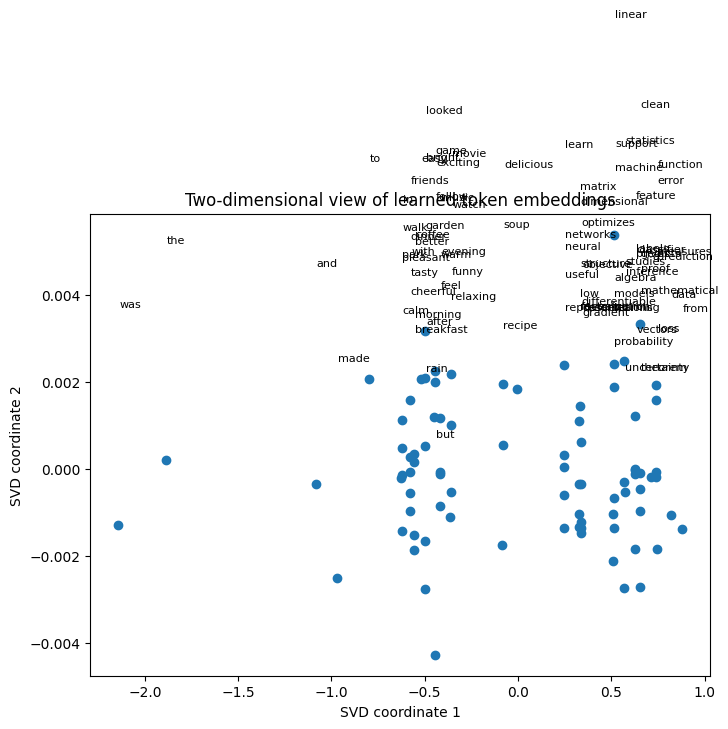

In [18]:
# Center embeddings before SVD visualization.
E_centered = E - E.mean(axis=0, keepdims=True)
U, S, Vt = np.linalg.svd(E_centered, full_matrices=False)
coords = E_centered @ Vt[:2].T

plt.figure(figsize=(8, 6))
plt.scatter(coords[:, 0], coords[:, 1])
for j, tok in id_to_token.items():
    if tok == "<unk>":
        continue
    plt.text(coords[j, 0] + 0.005, coords[j, 1] + 0.005, tok, fontsize=8)
plt.xlabel("SVD coordinate 1")
plt.ylabel("SVD coordinate 2")
plt.title("Two-dimensional view of learned token embeddings")
plt.show()


## Interpretation questions

1. Do technical tokens cluster together in the plot?
2. Do casual tokens cluster together?
3. Which tokens appear ambiguous or near the center?
4. What might happen if the training corpus were much larger and more diverse?


# Part 8. Predict new texts

The model can classify new texts by tokenizing, encoding with the training vocabulary, averaging embeddings, and applying the output layer.

Unknown words map to `<unk>`. This is a simple strategy. Modern models usually use subword tokenization to reduce the unknown-token problem.


In [19]:
def predict_texts(new_texts, E, W, b, vocab):
    tokenized = [tokenize(t) for t in new_texts]
    encoded = [encode(doc, vocab) for doc in tokenized]
    _, _, P = forward_avg_embedding(encoded, E, W, b)
    table = []
    for text, toks, ids, probs in zip(new_texts, tokenized, encoded, P):
        table.append({
            "text": text,
            "tokens": toks,
            "unknown_count": sum(1 for j in ids if j == vocab["<unk>"]),
            "prob_casual_0": probs[0],
            "prob_technical_1": probs[1],
            "predicted": int(np.argmax(probs)),
        })
    return pd.DataFrame(table)

new_texts = [
    "the proof uses gradients and probability",
    "the dinner was warm and delicious",
    "the model watched a movie about data",
    "optimization made the soup better",
]

predict_texts(new_texts, E, W, avg_results["b"], vocab).round(3)


,text,tokens,unknown_count,prob_casual_0,prob_technical_1,predicted
0,the proof uses gradients and probability,"[the, proof, uses, gradients, and, probability]",2,0.546,0.454,0
1,the dinner was warm and delicious,"[the, dinner, was, warm, and, delicious]",0,0.998,0.002,0
2,the model watched a movie about data,"[the, model, watched, a, movie, about, data]",3,0.193,0.807,1
3,optimization made the soup better,"[optimization, made, the, soup, better]",1,0.968,0.032,0


## Interpretation question

The last two examples mix technical and casual vocabulary. Does the model behave reasonably? Which words appear to dominate the decision?


# Part 9. Add one hidden ReLU layer

A linear output layer after average pooling computes

$$
z=hW+b.
$$

A one-hidden-layer network computes

$$
\begin{aligned}
u &= hA+a,\\
r &= \operatorname{ReLU}(u),\\
z &= rW+b.
\end{aligned}
$$

The ReLU activation is

$$
\operatorname{ReLU}(t)=\max(t,0).
$$

This model is still small, but it can learn nonlinear transformations of the averaged embedding vector.


In [20]:
def relu(U):
    return np.maximum(U, 0.0)


def relu_grad(U):
    return (U > 0).astype(float)


def forward_relu_embedding(encoded_docs, E, A, a, W, b):
    H = np.zeros((len(encoded_docs), E.shape[1]))
    for i, doc in enumerate(encoded_docs):
        H[i] = E[doc].mean(axis=0)
    U = H @ A + a
    R = relu(U)
    Z = R @ W + b
    P = softmax(Z)
    return H, U, R, Z, P


def loss_and_grads_relu_embedding(encoded_docs, y, E, A, a, W, b, l2=0.0):
    n = len(encoded_docs)
    H, U, R, Z, P = forward_relu_embedding(encoded_docs, E, A, a, W, b)
    loss = cross_entropy(P, y) + 0.5 * l2 * (np.sum(E * E) + np.sum(A * A) + np.sum(W * W))

    Gz = P.copy()
    Gz[np.arange(n), y] -= 1.0
    Gz /= n

    grad_W = R.T @ Gz + l2 * W
    grad_b = Gz.sum(axis=0)
    grad_R = Gz @ W.T
    grad_U = grad_R * relu_grad(U)
    grad_A = H.T @ grad_U + l2 * A
    grad_a = grad_U.sum(axis=0)
    grad_H = grad_U @ A.T

    grad_E = np.zeros_like(E)
    for i, doc in enumerate(encoded_docs):
        contribution = grad_H[i] / len(doc)
        for token_id in doc:
            grad_E[token_id] += contribution
    grad_E += l2 * E

    return loss, (grad_E, grad_A, grad_a, grad_W, grad_b), (H, U, R, Z, P)

print("ReLU helper functions defined.")


ReLU helper functions defined.


In [21]:
def train_relu_embedding(encoded_train, y_train, encoded_test, y_test,
                         embedding_dim=8, hidden_dim=10, epochs=1000, lr=2.0, l2=0.001, seed=5):
    rng_local = np.random.default_rng(seed)
    D = len(vocab)
    K = 2
    E = 0.05 * rng_local.normal(size=(D, embedding_dim))
    A = 0.05 * rng_local.normal(size=(embedding_dim, hidden_dim))
    a = np.zeros(hidden_dim)
    W = 0.05 * rng_local.normal(size=(hidden_dim, K))
    b = np.zeros(K)

    history = []
    for epoch in range(epochs):
        loss, grads, _ = loss_and_grads_relu_embedding(encoded_train, y_train, E, A, a, W, b, l2=l2)
        grad_E, grad_A, grad_a, grad_W, grad_b = grads
        history.append(loss)

        E -= lr * grad_E
        A -= lr * grad_A
        a -= lr * grad_a
        W -= lr * grad_W
        b -= lr * grad_b

    H_train, U_train, R_train, Z_train, P_train = forward_relu_embedding(encoded_train, E, A, a, W, b)
    H_test, U_test, R_test, Z_test, P_test = forward_relu_embedding(encoded_test, E, A, a, W, b)
    return {
        "E": E, "A": A, "a": a, "W": W, "b": b,
        "history": history,
        "P_train": P_train, "P_test": P_test,
        "train_accuracy": accuracy(P_train, y_train),
        "test_accuracy": accuracy(P_test, y_test),
        "train_loss": cross_entropy(P_train, y_train),
        "test_loss": cross_entropy(P_test, y_test),
    }

relu_results = train_relu_embedding(
    X_train_ids, y_train, X_test_ids, y_test,
    embedding_dim=8, hidden_dim=10, epochs=1000, lr=2.0, l2=0.001, seed=11
)

print("ReLU train loss:", round(relu_results["train_loss"], 4))
print("ReLU test loss:", round(relu_results["test_loss"], 4))
print("ReLU train accuracy:", relu_results["train_accuracy"])
print("ReLU test accuracy:", relu_results["test_accuracy"])


ReLU train loss: 0.0019
ReLU test loss: 0.4509
ReLU train accuracy: 1.0
ReLU test accuracy: 0.875


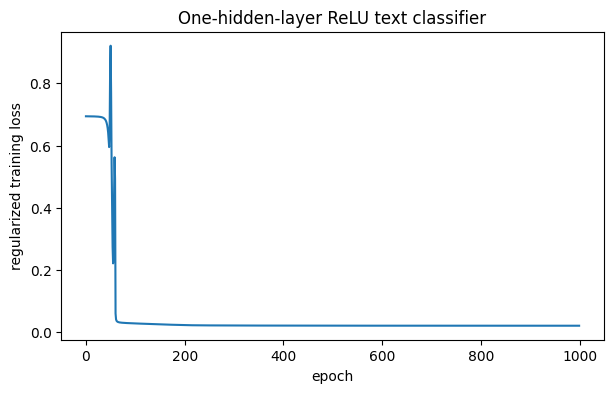

In [22]:
plt.figure(figsize=(7, 4))
plt.plot(relu_results["history"])
plt.xlabel("epoch")
plt.ylabel("regularized training loss")
plt.title("One-hidden-layer ReLU text classifier")
plt.show()


## Model comparison

The table below compares:

1. a fixed bag-of-words softmax classifier;
2. a trainable averaged-embedding classifier;
3. a trainable averaged-embedding classifier with a hidden ReLU layer.

On small data, more flexibility can help training accuracy but may not improve test behavior.


In [23]:
comparison = pd.DataFrame([
    {
        "model": "fixed bag-of-words softmax",
        "train_accuracy": accuracy(P_train_bow, y_train),
        "test_accuracy": accuracy(P_test_bow, y_test),
        "train_loss": cross_entropy(P_train_bow, y_train),
        "test_loss": cross_entropy(P_test_bow, y_test),
    },
    {
        "model": "averaged trainable embeddings",
        "train_accuracy": avg_results["train_accuracy"],
        "test_accuracy": avg_results["test_accuracy"],
        "train_loss": avg_results["train_loss"],
        "test_loss": avg_results["test_loss"],
    },
    {
        "model": "averaged embeddings + ReLU",
        "train_accuracy": relu_results["train_accuracy"],
        "test_accuracy": relu_results["test_accuracy"],
        "train_loss": relu_results["train_loss"],
        "test_loss": relu_results["test_loss"],
    },
])
comparison.round(4)


,model,train_accuracy,test_accuracy,train_loss,test_loss
0,fixed bag-of-words softmax,1.0,0.750,0.4806,0.6210
1,averaged trainable embeddings,1.0,0.875,0.0067,0.4418
2,averaged embeddings + ReLU,1.0,0.875,0.0019,0.4509


# Part 10. Temperature and confidence

Softmax temperature modifies logits before softmax:

$$
p_k(T)=\frac{\exp(z_k/T)}{\sum_{\ell}\exp(z_\ell/T)}.
$$

- Smaller $T$ makes probabilities sharper.
- Larger $T$ makes probabilities softer.

Temperature does not change the class ranking when $T>0$, but it changes confidence and cross-entropy.


In [24]:
# Get logits from the averaged-embedding model.
H_test, Z_test_avg, P_test_avg = forward_avg_embedding(X_test_ids, avg_results["E"], avg_results["W"], avg_results["b"])

rows = []
for T in [0.25, 0.5, 1.0, 2.0, 5.0]:
    P_T = softmax(Z_test_avg / T)
    rows.append({
        "temperature": T,
        "test_cross_entropy": cross_entropy(P_T, y_test),
        "test_accuracy": accuracy(P_T, y_test),
        "average_confidence": float(np.max(P_T, axis=1).mean()),
    })

temp_df = pd.DataFrame(rows)
temp_df.round(4)


,temperature,test_cross_entropy,test_accuracy,average_confidence
0,0.25,0.9588,0.875,0.9536
1,0.50,0.5680,0.875,0.9021
2,1.00,0.4418,0.875,0.8207
3,2.00,0.4688,0.875,0.7109
4,5.00,0.5692,0.875,0.5950


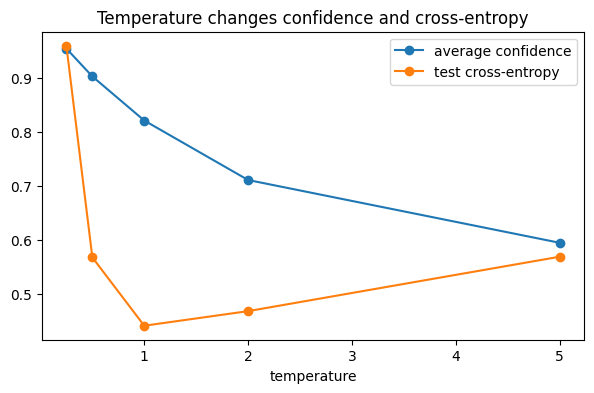

In [25]:
plt.figure(figsize=(7, 4))
plt.plot(temp_df["temperature"], temp_df["average_confidence"], marker="o", label="average confidence")
plt.plot(temp_df["temperature"], temp_df["test_cross_entropy"], marker="o", label="test cross-entropy")
plt.xlabel("temperature")
plt.title("Temperature changes confidence and cross-entropy")
plt.legend()
plt.show()


## Interpretation question

A model can be accurate but overconfident. In the table above, which temperature gives the smallest cross-entropy? Which gives the highest confidence?

Why are these not necessarily the same objective?


# Part 11. Exercises

## Exercise 1. Dimension check

For the averaged-embedding model, suppose:

- $d=5000$ vocabulary items;
- $m=64$ embedding dimensions;
- $K=3$ classes;
- a batch has $n=32$ examples.

Write the shapes of $E$, $H$, $W$, $b$, $Z$, and $P$.

## Exercise 2. Learning rate experiment

Run the averaged-embedding training with learning rates

$$
0.5,\ 1.0,\ 2.0,\ 4.0,\ 8.0.
$$

For each learning rate, record the final training loss and test accuracy. What happens if the learning rate is too small or too large?

## Exercise 3. Embedding dimension experiment

Train the averaged-embedding model with embedding dimensions

$$
2,\ 4,\ 8,\ 16.
$$

How does the dimension affect training loss, test loss, and interpretability of the 2D plot?

## Exercise 4. Remove common words

Remove words such as `and`, `the`, `was`, and `a` from the tokenized data. Rebuild the vocabulary and retrain the model. Does the interpretation of token directions improve?

## Exercise 5. Unknown-token stress test

Create five new examples with words that do not appear in the training vocabulary. Count how many tokens become `<unk>`. How stable are the predictions?

## Exercise 6. Gradient reasoning

Explain in words why each token occurrence in a document receives $1/T$ times the gradient of the pooled vector.


# Part 12. AI-assisted auditing prompts

Use an AI assistant as a reviewer, not as an oracle. Try prompts like these after you understand the code.

## Prompt 1. Dimension audit

> I implemented an averaged-embedding text classifier with $E$ of shape $(d,m)$, pooled document matrix $H$, and output matrix $W$. Check the dimensions of every matrix multiplication and explain any inconsistency.

## Prompt 2. Gradient audit

> Explain why the gradient of softmax cross-entropy with respect to logits is $p-y$. Then audit my NumPy code for the embedding-gradient update.

## Prompt 3. Overfitting audit

> The training loss is very small but the test loss is not. Give mathematical and statistical reasons this can happen for a neural text classifier trained on a tiny dataset.

## Prompt 4. Representation audit

> My averaged-embedding model ignores word order. Give examples of text-classification tasks where this is acceptable and tasks where it is dangerous.


# Part 13. Mini-project

Build a tiny neural classifier for a different two-class text problem.

Suggested topics:

1. course description vs social message;
2. research abstract vs news headline;
3. mathematical statement vs everyday statement;
4. positive review vs negative review.

Your mini-project should include:

1. at least 20 short examples;
2. a train/test split;
3. a vocabulary with `<unk>`;
4. a fixed bag-of-words baseline;
5. an averaged-embedding classifier;
6. one plot of training loss;
7. one table of test predictions;
8. a short audit of token directions and unknown-token behavior;
9. a paragraph explaining whether a neural model is justified for such a small dataset.


# Summary

In this lab, we built neural text classifiers from first principles.

The essential ideas are:

- text must be converted into token indices before it can enter an embedding layer;
- an embedding layer is a trainable matrix lookup;
- average pooling maps variable-length documents to fixed-dimensional vectors;
- softmax converts logits into probabilities;
- cross-entropy trains conditional class probabilities;
- the gradient of softmax cross-entropy with respect to logits is $p-y$;
- backpropagation distributes the document-level gradient back to token embedding rows;
- hidden layers add flexibility but can overfit small text datasets;
- temperature changes confidence without changing the ranking of logits.

The next labs move from unordered averaged embeddings to sequence models, where word order becomes part of the computation.
